# 02 · Data Engineering — Synthetic Inventory & Demand Layer

**Why this notebook exists:** every public dataset audited for this project (see the Inventory Intelligence Sourcebook, Section A.3) is missing the one field Inventory Health, ABC/XYZ, Safety Stock, and ROP all depend on — **real on-hand stock over time**. This notebook builds that layer, calibrated to the real Brunel network (plant capacities, handling costs, and true freight lead times), and writes the full star schema both as Parquet files and a single SQLite database Power BI can connect to directly.

**What this is not:** a copy of real Metso/Brunel operational data. It's a documented simulation — see `docs/SYNTHETIC_DATA_METHODOLOGY.md` for every assumption, formula, and distribution used. License: CC0 (this project's own work — see `docs/DATA_PROVENANCE.md`).

In [1]:
import sys
from pathlib import Path

try:
    import google.colab  # noqa: F401
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    PROJECT_ROOT = Path('/content/drive/MyDrive/inventory-intelligence-gsc')
except ImportError:
    PROJECT_ROOT = Path.cwd()
    if PROJECT_ROOT.name == "notebooks":
        PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT / "src"))

import simulate_inventory as sim
import pandas as pd
import matplotlib.pyplot as plt

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
SYNTHETIC_DIR = PROJECT_ROOT / "data" / "synthetic"
DB_PATH = PROJECT_ROOT / "data" / "inventory_performance.db"

print(f"Simulation window: {sim.SIM_START.date()} -> {sim.SIM_END.date()}  ({sim.N_DAYS} days)")

Simulation window: 2024-01-01 -> 2025-12-31  (731 days)


## 1. Run the simulation

Builds `Dim_Warehouse`, `Dim_SKU` (with ABC classification from a Pareto cut on synthetic annual value), computes each series' EOQ / Safety Stock / Reorder Point from the real lead times and warehouse costs, then simulates day-by-day on-hand stock, backorders, and stockouts under a continuous-review (s, S)-style policy.

In [2]:
sim.simulate_all(PROCESSED_DIR, SYNTHETIC_DIR)

SKU x Warehouse series simulated: 2,035
Fact_Inventory rows: 1,487,585
Fact_Demand rows: 1,487,585
Fact_Orders rows: 17,119
Overall simulated stockout-day rate: 0.26%
ABC mix: {'C': 0.634, 'B': 0.222, 'A': 0.144}


## 2. Load everything into one SQLite star schema (facts + dims + the real Brunel tables), for Power BI and Python to share a single source of truth

In [3]:
sim.load_into_sqlite(SYNTHETIC_DIR, PROCESSED_DIR, DB_PATH)
print("Database:", DB_PATH, f"({DB_PATH.stat().st_size/1e6:.1f} MB)")

Loaded star schema into /home/claude/inventory-intelligence-gsc/data/inventory_performance.db
Database: /home/claude/inventory-intelligence-gsc/data/inventory_performance.db (139.0 MB)


## 3. Sanity-check the simulation before building anything on top of it

In [4]:
fact_inventory = pd.read_parquet(SYNTHETIC_DIR / "fact_inventory.parquet")
fact_demand = pd.read_parquet(SYNTHETIC_DIR / "fact_demand.parquet")
fact_orders = pd.read_parquet(SYNTHETIC_DIR / "fact_orders.parquet")
dim_sku = pd.read_parquet(SYNTHETIC_DIR / "dim_sku.parquet")
dim_wh = pd.read_parquet(SYNTHETIC_DIR / "dim_warehouse.parquet")
dim_policy = pd.read_parquet(SYNTHETIC_DIR / "dim_replenishment_policy.parquet")

print("Fact_Inventory:", fact_inventory.shape)
print("Fact_Demand:", fact_demand.shape)
print("Fact_Orders:", fact_orders.shape)
print()
print("ABC mix (share of SKUs):")
print(dim_sku["abc_class"].value_counts(normalize=True).round(3))
print()
by_class = fact_inventory.merge(dim_sku[["sku", "abc_class"]], on="sku")
print("Stockout-day rate by ABC class (should be lowest for A, highest for C):")
print(by_class.groupby("abc_class")["stockout_flag"].mean().round(4))
print()
series_stockout = fact_inventory.groupby(["sku", "warehouse_id"])["stockout_flag"].max()
print(f"Share of SKU x Warehouse series with >=1 stockout over 2 years: {series_stockout.mean():.1%}")

Fact_Inventory: (1487585, 7)
Fact_Demand: (1487585, 4)
Fact_Orders: (17119, 8)

ABC mix (share of SKUs):
abc_class
C    0.634
B    0.222
A    0.144
Name: proportion, dtype: float64

Stockout-day rate by ABC class (should be lowest for A, highest for C):
abc_class
A    0.0046
B    0.0028
C    0.0020
Name: stockout_flag, dtype: float64



Share of SKU x Warehouse series with >=1 stockout over 2 years: 68.9%


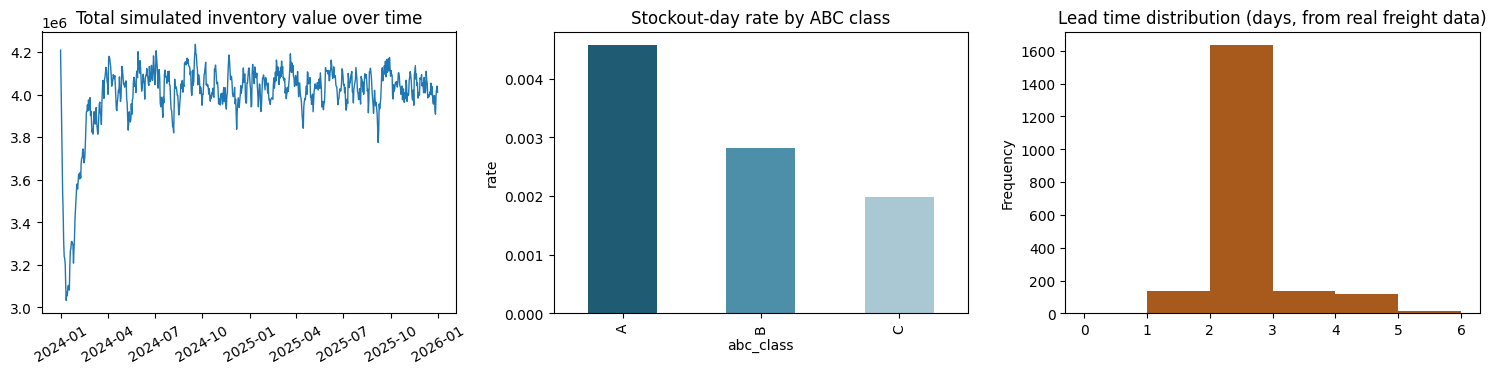

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

daily_value = fact_inventory.merge(dim_sku[["sku", "unit_cost"]], on="sku")
daily_value["inv_value"] = daily_value["on_hand_qty"] * daily_value["unit_cost"]
total_by_date = daily_value.groupby("date")["inv_value"].sum()
axes[0].plot(total_by_date.index, total_by_date.values, linewidth=1)
axes[0].set_title("Total simulated inventory value over time")
axes[0].tick_params(axis="x", rotation=30)

by_class.groupby("abc_class")["stockout_flag"].mean().plot(kind="bar", ax=axes[1], color=["#1f5c73", "#4d8fa8", "#a9c8d4"])
axes[1].set_title("Stockout-day rate by ABC class")
axes[1].set_ylabel("rate")

dim_policy["lead_time_days"].plot(kind="hist", bins=range(0, dim_policy["lead_time_days"].max() + 2), ax=axes[2], color="#a85a1d")
axes[2].set_title("Lead time distribution (days, from real freight data)")

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "docs" / "phase2_validation_charts.png", dpi=130)
plt.show()

## 4. What's next

`data/inventory_performance.db` now holds the full star schema (real Brunel
network tables + the synthetic Fact_Inventory / Fact_Demand / Fact_Orders /
Dim_SKU / Dim_Warehouse / Dim_Date). Notebook `03_descriptive_diagnostic.ipynb`
builds the KPI and ABC/XYZ layer directly on top of this database.